In [ ]:
%matplotlib inline
from wrapper import BasicEnvironmentRGB, DomainRandomization, RandomColorReplace
import gymnasium as gym
from gymnasium.wrappers import FrameStackObservation, TransformObservation, ResizeObservation
from matplotlib import pyplot as plt
from rltesting.torch_rl.utils import random_sample_single_env
from rltesting.torch_rl.buffers import ReplayBuffer
from rltesting.torch_rl.models import MLP
from fvd_models import Encoder, Decoder, AEVAE, DoubleAutoEncoder
import numpy as np
import torch
import skdim
import ale_py
import os

np.random.seed(42)
torch.manual_seed(0)
# gym.utils.seeding.np_random(0)

to_numpy = lambda x: x.cpu().detach().numpy()
framestack = 2
latent_dim = None
obs_shape = 64
data_steps = 200000
num_epochs = 50
steps_per_epoch = 1000
gym.register_envs(ale_py)
env = gym.make('ALE/Boxing-v5', render_mode="rgb_array")
env = BasicEnvironmentRGB(env)
env = ResizeObservation(env, (obs_shape, obs_shape))
env = FrameStackObservation(env, stack_size=framestack)
env = TransformObservation(env, lambda obs: np.transpose(obs, (1, 2, 0, 3)), observation_space=gym.spaces.Box(0, 255, (framestack, 3, obs_shape, obs_shape), dtype=np.uint8))
env = TransformObservation(env, lambda obs: np.reshape(obs, (obs_shape, obs_shape, 3 * framestack)), observation_space=gym.spaces.Box(0, 255, (obs_shape, obs_shape, 3 * framestack), dtype=np.uint8))
buffer_shapes = [(obs_shape, obs_shape, 3 * framestack), (), (), ()]
dtypes = [np.uint8, np.float32, np.float32, np.float32]
buffer = ReplayBuffer(buffer_shapes, dtypes, buffer_size=data_steps)

In [ ]:
obs, _ = env.reset()

In [ ]:
plt.imshow(obs[:, :, :3] / 255)
print(obs.shape)

In [ ]:
buffer_shapes = [(obs_shape, obs_shape, 3 * framestack), (), (), ()]
dtypes = [np.uint8, np.float32, np.float32, np.float32]
buffer = ReplayBuffer(buffer_shapes, dtypes, buffer_size=data_steps)
filepath = "atari_buffer.npz"
if os.path.isfile(filepath):
  buffer.load(filepath)
else:
  samples = random_sample_single_env(env, num_steps=data_steps)
  for i in range(data_steps):
      buffer.add_sample([samples[j][i] for j in range(len(samples))].copy())
  buffer.save(filepath=filepath)

In [ ]:
if os.path.isfile('boxing_aevae.pt'):
    print("Checkpoint found, skipping training.")
else:
    encoder = Encoder(framestack, latent_dim, obs_shape).cuda()
    decoder = Decoder(encoder.conv_dim, framestack, latent_dim).cuda()
    opt = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), 3e-4)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.97)

In [ ]:
if os.path.isfile('boxing_aevae.pt'):
    print("Checkpoint found, skipping training.")
else:
    losses = []
    for i in range(1, num_epochs + 1):
        for _ in range(steps_per_epoch):
            samples = buffer.sample(256)
            obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()
            latent = encoder(obs)
            reconstruction = decoder(latent)
            loss = torch.nn.functional.mse_loss(reconstruction, obs)
            loss.backward()
            opt.step()
            opt.zero_grad()
            losses.append(loss.detach().cpu().numpy())
        scheduler.step()
        if i % 10 == 0:
            print(i * steps_per_epoch)
    plt.plot(losses)

In [ ]:
if os.path.isfile('boxing_aevae.pt'):
    print("Checkpoint found, skipping training.")
else:
    num_img = 4
    fig, axs = plt.subplots(nrows=num_img, ncols=2, figsize=(4, 2 * num_img))
    for i in range(4):
        axs[i][0].imshow(reconstruction[i].detach().cpu().transpose(-3, -1).numpy()[:, :, :3])
        axs[i][0].axis("off")
        axs[i][1].imshow(samples[0][i][:, :, :3])
        axs[i][1].axis("off")
    plt.tight_layout()
    plt.show()
    fig.savefig("direct_dim.png")

In [ ]:
if os.path.isfile('boxing_aevae.pt'):
    print("Checkpoint found, skipping training.")
else:
    latent_ID = []
    image_ID = []

    for _ in range(20):
        samples = buffer.sample(2048)
        obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()
        latent = encoder(obs)
        unique_latents = np.unique(latent.detach().cpu().numpy(), axis=0)
        unique_obs = np.unique(obs.detach().cpu().numpy(), axis=0).reshape(-1, 3 * framestack*obs_shape*obs_shape)

        latent_ID.append(skdim.id.MLE().fit(unique_latents).dimension_)
        image_ID.append(skdim.id.MLE().fit(unique_obs).dimension_)

    print(f"Latent ID: {np.mean(latent_ID)} +- {np.std(latent_ID)}")
    print(f"Image ID: {np.mean(image_ID)} +- {np.std(image_ID)}")


In [ ]:
if os.path.isfile('boxing_aevae.pt'):
    print("Checkpoint found, skipping training.")
else:
    intrinsic_dim = round(np.mean(latent_ID))
    double_autoencoder = DoubleAutoEncoder(encoder, decoder, latent_dim, intrinsic_dim, hidden_dim=256).cuda()
    int_opt = torch.optim.AdamW(double_autoencoder.parameters(), 3e-4)
    int_scheduler = torch.optim.lr_scheduler.ExponentialLR(int_opt, gamma=0.97)
    losses = []
    for i in range(1, num_epochs + 1):
        for _ in range(steps_per_epoch):
            samples = buffer.sample(256)
            obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()
            loss = double_autoencoder.reconstruction_loss(obs)
            loss.backward()
            int_opt.step()
            int_opt.zero_grad()
            losses.append(loss.detach().cpu().numpy())
        int_scheduler.step()
        if i % 10 == 0:
            print(i * steps_per_epoch)
    plt.plot(losses)

In [ ]:
# ---- Save/Load AEVAE ---- #
aevae_path = 'boxing_aevae.pt'
if os.path.isfile(aevae_path):
    print("Loading saved AEVAE...")
    ckpt = torch.load(aevae_path, weights_only=False)
    intrinsic_dim = ckpt['intrinsic_dim']
    latent_dim = ckpt['latent_dim']
    encoder = Encoder(framestack, latent_dim, obs_shape).cuda()
    decoder = Decoder(encoder.conv_dim, framestack, latent_dim).cuda()
    double_autoencoder = AEVAE(encoder, decoder, latent_dim, intrinsic_dim).cuda()
    double_autoencoder.load_state_dict(ckpt['weights'])
    print(f"Loaded. Intrinsic dim: {intrinsic_dim}, Latent dim: {latent_dim}")
else:
    print("Saving AEVAE...")
    torch.save({
        'weights': double_autoencoder.state_dict(),
        'intrinsic_dim': intrinsic_dim,
        'latent_dim': latent_dim,
    }, aevae_path)
    print("Saved.") 

Saving AEVAE...
Saved.


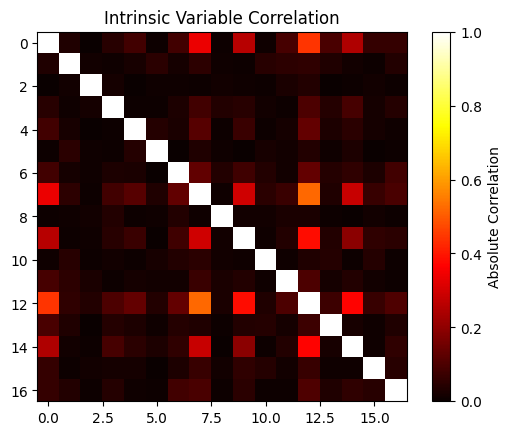

In [ ]:
plt.close('all')
%matplotlib inline
num_samples = 2048
with torch.no_grad():
    samples = buffer.sample(num_samples)
    obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()
    intrinsic = double_autoencoder.double_encode(obs).cpu().numpy()

corr = np.corrcoef(intrinsic, rowvar=False)
plt.imshow(np.abs(corr), cmap="hot", vmin=0, vmax=1)
plt.colorbar(label="Absolute Correlation")
plt.title("Intrinsic Variable Correlation")
plt.show()

In [ ]:
for name, module in [
    ("Stage 1 Encoder (conv + linear)", double_autoencoder.encoder),
    ("Stage 1 Decoder (linear + conv)", double_autoencoder.decoder),
    ("Intrinsic Encoder (MLP)",         double_autoencoder.intrinsic_encoder),
    ("Intrinsic mu head",               double_autoencoder.intrinsic_mu),
    ("Intrinsic logvar head",           double_autoencoder.intrinsic_logvar),
    ("Intrinsic Decoder (MLP)",         double_autoencoder.intrinsic_decoder),
]:
    n = sum(p.numel() for p in module.parameters())
    print(f"{name:<40s}  {n:>10,}")

total = sum(p.numel() for p in double_autoencoder.parameters())
print(f"{'TOTAL':<40s}  {total:>10,}")

Stage 1 Encoder (conv + linear)              173,920
Stage 1 Decoder (linear + conv)              173,798
Intrinsic Encoder (MLP)                      721,920
Intrinsic mu head                              4,369
Intrinsic logvar head                          4,369
Intrinsic Decoder (MLP)                      530,944
TOTAL                                      1,609,320


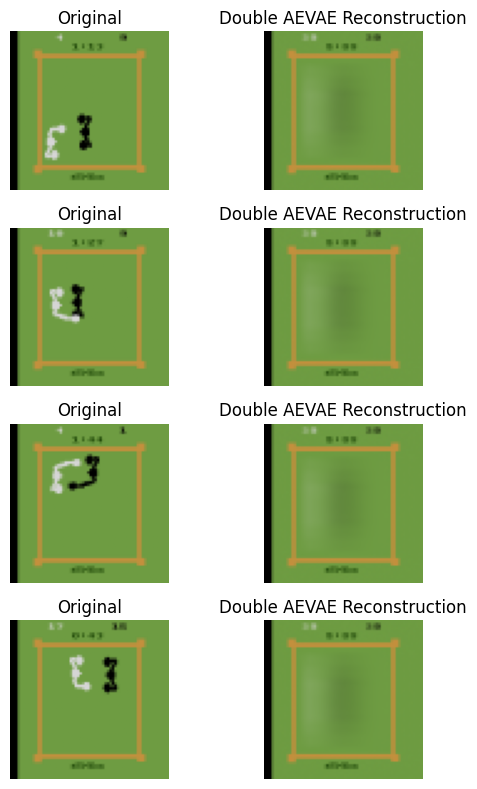

In [ ]:
num_img = 4
samples = buffer.sample(num_img)

obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()
with torch.no_grad():
    latent = double_autoencoder.double_encode_deterministic(obs)
    reconstruction_double = double_autoencoder.double_decode(latent)

fig, axs = plt.subplots(num_img, 2, figsize=(6, 2 * num_img))
for i in range(num_img):
    orig_img = samples[0][i].astype(np.float32) / 255.0
    recon_img = reconstruction_double[i].detach().cpu().transpose(-3, -1).numpy()

    axs[i, 0].imshow(orig_img[:, :, :3])
    axs[i, 0].set_title("Original")
    axs[i, 0].axis("off")

    axs[i, 1].imshow(recon_img[:, :, :3])
    axs[i, 1].set_title("Double AEVAE Reconstruction")
    axs[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# # ---- SARSA(λ) + RFF on Boxing ---- #
# import copy
# import time

# aevae = copy.deepcopy(double_autoencoder)
# aevae.eval()

# num_actions = env.action_space.n
# num_features = 4096  # more features for higher dim
# bandwidth = 2.0      # start here, will need tuning
# total_features = num_features * num_actions
# encode_batch_size = 128

# np.random.seed(42)
# W_rff = np.random.randn(num_features, intrinsic_dim) / bandwidth
# b_rff = np.random.uniform(0, 2 * np.pi, num_features)
# np.random.seed(None)

# w = np.zeros(total_features)
# alpha = 0.02
# lam = 0.9
# gamma = 0.99  # Boxing is not purely episodic like Acrobot
# max_timesteps = 10_000_000
# num_episodes = 5000

# # Compute normalization stats from random episodes
# print("Computing normalization stats...")
# all_intrinsic = []
# for _ in range(20):
#     obs, _ = env.reset()
#     done = False
#     ep_obs = [np.array(obs)]
#     while not done:
#         obs, _, term, trunc, _ = env.step(env.action_space.sample())
#         ep_obs.append(np.array(obs))
#         done = term or trunc
#     with torch.no_grad():
#         batch = np.stack(ep_obs)
#         t = (torch.tensor(batch).float().transpose(-3, -1) / 255).cuda()
#         raw = to_numpy(aevae.double_encode_deterministic(t))
#         all_intrinsic.append(raw)

# all_intrinsic = np.concatenate(all_intrinsic, axis=0)
# means = all_intrinsic.mean(axis=0)
# stds = all_intrinsic.std(axis=0)
# stds[stds == 0] = 1.0
# print(f"Stats from {len(all_intrinsic)} observations, intrinsic_dim={intrinsic_dim}")

# def encode_obs(obs):
#     with torch.no_grad():
#         t = (torch.tensor(np.array(obs)).unsqueeze(0).float().transpose(-3, -1) / 255).cuda()
#         raw = to_numpy(aevae.double_encode_deterministic(t)).squeeze()
#         return (raw - means) / stds

# def batch_encode(obs_array):
#     with torch.no_grad():
#         results = []
#         for i in range(0, len(obs_array), encode_batch_size):
#             batch = obs_array[i:i+encode_batch_size]
#             t = (torch.tensor(batch).float().transpose(-3, -1) / 255).cuda()
#             raw = to_numpy(aevae.double_encode_deterministic(t))
#             results.append(raw)
#         encoded = np.concatenate(results, axis=0)
#         return (encoded - means) / stds

# def rff_z(state):
#     return np.cos(W_rff @ state + b_rff) * np.sqrt(2.0 / num_features)

# def Q_all(state):
#     z = rff_z(state)
#     qs = np.zeros(num_actions)
#     for a in range(num_actions):
#         s = a * num_features
#         qs[a] = w[s:s + num_features] @ z
#     return qs

# def pick_action(state, eps):
#     if np.random.random() < eps:
#         return np.random.randint(num_actions)
#     return np.argmax(Q_all(state))

# # ---- Training loop ---- #
# time_collect = 0
# time_encode = 0
# time_sarsa = 0

# returns = []
# timestep_checkpoints = []
# total_steps = 0
# ep = 0
# t_start = time.time()

# while total_steps < max_timesteps and ep < num_episodes:
#     epsilon = max(0.05, 1.0 - ep / 1000)

#     # Phase 1: Collect episode
#     t0 = time.time()
#     obs, _ = env.reset()
#     episode_obs = [np.array(obs)]
#     episode_actions = []
#     episode_rewards = []

#     S = encode_obs(obs)
#     A = pick_action(S, epsilon)

#     while True:
#         obs_next, R, terminated, truncated, _ = env.step(A)
#         done = terminated or truncated
#         episode_actions.append(A)
#         episode_rewards.append(R)
#         total_steps += 1

#         if done:
#             break

#         episode_obs.append(np.array(obs_next))
#         S = encode_obs(obs_next)
#         A = pick_action(S, epsilon)

#     time_collect += time.time() - t0

#     # Phase 2: Batch encode
#     t0 = time.time()
#     all_states = batch_encode(np.stack(episode_obs))
#     time_encode += time.time() - t0

#     # Phase 3: SARSA(λ) with sparse traces
#     t0 = time.time()
#     trace = np.zeros(total_features)
#     T = len(episode_actions)

#     for t in range(T):
#         S = all_states[t]
#         A = episode_actions[t]
#         R = episode_rewards[t]
#         z = rff_z(S)

#         s = A * num_features
#         q_sa = w[s:s + num_features] @ z

#         if t == T - 1:
#             td_error = R - q_sa
#         else:
#             S_next = all_states[t + 1]
#             A_next = episode_actions[t + 1]
#             z_next = rff_z(S_next)
#             s_next = A_next * num_features
#             q_next = w[s_next:s_next + num_features] @ z_next
#             td_error = R + gamma * q_next - q_sa

#         trace *= gamma * lam
#         trace[s:s + num_features] = z
#         nz = np.nonzero(trace)[0]
#         w[nz] += alpha * td_error * trace[nz]
#         trace[np.abs(trace) < 1e-4] = 0.0

#     time_sarsa += time.time() - t0

#     returns.append(sum(episode_rewards))
#     timestep_checkpoints.append(total_steps)
#     ep += 1

#     if ep % 25 == 0:
#         elapsed = time.time() - t_start
#         avg = np.mean(returns[-25:])
#         print(f"Steps: {total_steps:>8d} | Episode {ep:4d} | "
#               f"Avg Return (last 25): {avg:7.1f} | Epsilon: {epsilon:.3f} | "
#               f"Time: {elapsed:.0f}s")
#         print(f"  Collect: {time_collect:.1f}s | Encode: {time_encode:.1f}s | "
#               f"SARSA: {time_sarsa:.1f}s")

# # ---- Plot ---- #
# window = 25
# smoothed = np.convolve(returns, np.ones(window)/window, mode='valid')
# smoothed_steps = [timestep_checkpoints[i] for i in range(window-1, len(timestep_checkpoints))]
# plt.plot(timestep_checkpoints, returns, alpha=0.3, label='Raw')
# plt.plot(smoothed_steps, smoothed, label=f'{window}-ep avg')
# plt.xlabel('Timesteps'); plt.ylabel('Return')
# plt.title('SARSA(λ) + RFF - Boxing'); plt.legend(); plt.show()

# total = time_collect + time_encode + time_sarsa
# print(f"\n=== Final Timing Breakdown ===")
# print(f"Collect: {time_collect:7.1f}s ({100*time_collect/total:.0f}%)")
# print(f"Encode:  {time_encode:7.1f}s ({100*time_encode/total:.0f}%)")
# print(f"SARSA:   {time_sarsa:7.1f}s ({100*time_sarsa/total:.0f}%)")

In [ ]:
# # ---- SARSA(λ) + Hashed Tile Coding on Boxing ---- #
# import copy
# import time
# from tiles import tiles  # your tiles3.py

# aevae = copy.deepcopy(double_autoencoder)
# aevae.eval()

# num_actions = env.action_space.n
# num_tiles_per_dim = 2
# num_tilings = 64  # 4 * 15 = 60, round up to 64
# hash_size = 2 ** 21  # 1M - power of 2 for best hashing

# w = np.zeros(hash_size)
# alpha = 0.2 / num_tilings
# lam = 0.9
# gamma = 0.99
# max_timesteps = 5_000_000
# num_episodes = 10000
# encode_batch_size = 128

# # Normalization stats
# print("Computing normalization stats...")
# all_intrinsic = []
# for _ in range(20):
#     obs, _ = env.reset()
#     done = False
#     ep_obs = [np.array(obs)]
#     while not done:
#         obs, _, term, trunc, _ = env.step(env.action_space.sample())
#         ep_obs.append(np.array(obs))
#         done = term or trunc
#     with torch.no_grad():
#         batch = np.stack(ep_obs)
#         t = (torch.tensor(batch).float().transpose(-3, -1) / 255).cuda()
#         raw = to_numpy(aevae.double_encode_deterministic(t))
#         all_intrinsic.append(raw)

# all_intrinsic = np.concatenate(all_intrinsic, axis=0)
# means = all_intrinsic.mean(axis=0)
# stds = all_intrinsic.std(axis=0)
# stds[stds == 0] = 1.0
# mins = np.full(intrinsic_dim, -3.0)
# scale = np.full(intrinsic_dim, num_tiles_per_dim / 6.0)

# print(f"Intrinsic dim: {intrinsic_dim}, Num tilings: {num_tilings}, Hash size: {hash_size}")

# def encode_obs(obs):
#     with torch.no_grad():
#         t = (torch.tensor(np.array(obs)).unsqueeze(0).float().transpose(-3, -1) / 255).cuda()
#         raw = to_numpy(aevae.double_encode_deterministic(t)).squeeze()
#         return (raw - means) / stds

# def batch_encode(obs_array):
#     with torch.no_grad():
#         results = []
#         for i in range(0, len(obs_array), encode_batch_size):
#             batch = obs_array[i:i+encode_batch_size]
#             t = (torch.tensor(batch).float().transpose(-3, -1) / 255).cuda()
#             raw = to_numpy(aevae.double_encode_deterministic(t))
#             results.append(raw)
#         return (np.concatenate(results, axis=0) - means) / stds

# def get_tiles(state, action):
#     scaled = ((state - mins) * scale).tolist()
#     return tiles(hash_size, num_tilings, scaled, ints=[action])

# def Q(state, action):
#     return np.sum(w[get_tiles(state, action)])

# def Q_all(state):
#     return np.array([Q(state, a) for a in range(num_actions)])

# def pick_action(state, eps):
#     if np.random.random() < eps:
#         return np.random.randint(num_actions)
#     return np.argmax(Q_all(state))

# # ---- Training loop ---- #
# time_collect = 0
# time_encode = 0
# time_sarsa = 0

# returns = []
# timestep_checkpoints = []
# total_steps = 0
# ep = 0
# t_start = time.time()

# while total_steps < max_timesteps and ep < num_episodes:
#     epsilon = max(0.05, 1.0 - ep / 1000)

#     # Phase 1: Collect
#     t0 = time.time()
#     obs, _ = env.reset()
#     episode_obs = [np.array(obs)]
#     episode_actions = []
#     episode_rewards = []

#     S = encode_obs(obs)
#     A = pick_action(S, epsilon)

#     while True:
#         obs_next, R, terminated, truncated, _ = env.step(A)
#         done = terminated or truncated
#         episode_actions.append(A)
#         episode_rewards.append(R)
#         total_steps += 1

#         if done:
#             break

#         episode_obs.append(np.array(obs_next))
#         S = encode_obs(obs_next)
#         A = pick_action(S, epsilon)

#     time_collect += time.time() - t0

#     # Phase 2: Batch encode
#     t0 = time.time()
#     all_states = batch_encode(np.stack(episode_obs))
#     time_encode += time.time() - t0

#     # Phase 3: SARSA(λ) with sparse traces
#     t0 = time.time()
#     trace_indices = set()
#     e = np.zeros(hash_size)
#     T = len(episode_actions)

#     for t in range(T):
#         active = get_tiles(all_states[t], episode_actions[t])
#         q_sa = np.sum(w[active])

#         if t == T - 1:
#             td_error = episode_rewards[t] - q_sa
#         else:
#             active_next = get_tiles(all_states[t + 1], episode_actions[t + 1])
#             q_next = np.sum(w[active_next])
#             td_error = episode_rewards[t] + gamma * q_next - q_sa

#         # Decay traces
#         if trace_indices:
#             trace_list = np.array(list(trace_indices))
#             e[trace_list] *= gamma * lam
#             dead = trace_list[np.abs(e[trace_list]) < 1e-4]
#             e[dead] = 0.0
#             trace_indices -= set(dead)

#         # Replacing traces
#         for i in active:
#             e[i] = 1.0
#             trace_indices.add(i)

#         # Update
#         if trace_indices:
#             trace_list = np.array(list(trace_indices))
#             w[trace_list] += alpha * td_error * e[trace_list]

#     time_sarsa += time.time() - t0

#     returns.append(sum(episode_rewards))
#     timestep_checkpoints.append(total_steps)
#     ep += 1

#     if ep % 25 == 0:
#         elapsed = time.time() - t_start
#         avg = np.mean(returns[-25:])
#         print(f"Steps: {total_steps:>8d} | Episode {ep:4d} | "
#               f"Avg Return (last 25): {avg:7.1f} | Epsilon: {epsilon:.3f} | "
#               f"Time: {elapsed:.0f}s")
#         print(f"  Collect: {time_collect:.1f}s | Encode: {time_encode:.1f}s | "
#               f"SARSA: {time_sarsa:.1f}s")

# # ---- Plot ---- #
# window = 25
# smoothed = np.convolve(returns, np.ones(window)/window, mode='valid')
# smoothed_steps = [timestep_checkpoints[i] for i in range(window-1, len(timestep_checkpoints))]
# plt.plot(timestep_checkpoints, returns, alpha=0.3, label='Raw')
# plt.plot(smoothed_steps, smoothed, label=f'{window}-ep avg')
# plt.xlabel('Timesteps'); plt.ylabel('Return')
# plt.title('SARSA(λ) + Hashed Tile Coding - Boxing'); plt.legend(); plt.show()

# total = time_collect + time_encode + time_sarsa
# print(f"\n=== Timing ===")
# print(f"Collect: {time_collect:7.1f}s ({100*time_collect/total:.0f}%)")
# print(f"Encode:  {time_encode:7.1f}s ({100*time_encode/total:.0f}%)")
# print(f"SARSA:   {time_sarsa:7.1f}s ({100*time_sarsa/total:.0f}%)")